In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files
from scipy.stats import ttest_ind


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
uploaded = files.upload()

Saving Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv to Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv


In [3]:
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

df.head()


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

(7500, 16)

In [5]:
df.describe().round(2)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24,0.71
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72,0.45
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58,0.00
25%,22.00,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96,0.00
50%,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26,1.00
75%,31.00,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54,1.00
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88,1.00


In [6]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [7]:
df['gender'].value_counts()

,count
gender,
Male,2553
Other,2486
Female,2461


In [8]:
df.drop(columns=['transaction_id', 'user_id'],inplace=True)
mode_val = df['addiction_level'].mode()[0]
df['addiction_level'].fillna(mode_val, inplace=True)
df['gender'] = df['gender'].map({'Other': 0, 'Male': 1, 'Female': 2})
df['stress_level'] = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['addiction_level'] = df['addiction_level'].map({'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3})
df.isnull().sum()


/tmp/ipykernel_519/1906365954.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['addiction_level'].fillna(mode_val, inplace=True)


,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0
app_opens_per_day,0
weekend_screen_time,0


In [9]:
df['gender'].unique()

array([1, 0, 2])

In [10]:
missing=df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("No missing values found,dataset is clean!")

No missing values found,dataset is clean!


In [11]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [12]:
cols = ['gender', 'stress_level', 'addiction_level', 'academic_work_impact']
for col in cols:
    print(f'\n{col}: {df[col].unique().tolist()}') #el to list 3mlt elkoma w unique no repitition
    print(df[col].value_counts())


gender: [1, 0, 2]
gender
1    2553
0    2486
2    2461
Name: count, dtype: int64

stress_level: [1, 2, 0]
stress_level
2    2560
0    2503
1    2437
Name: count, dtype: int64

addiction_level: [2, 1, 3]
addiction_level
2    3693
3    2434
1    1373
Name: count, dtype: int64

academic_work_impact: ['Yes', 'No']
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64


# **visualizations**



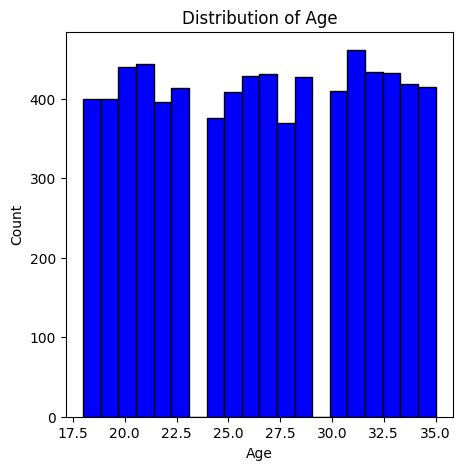

Age → Mean: 26.57 | Median: 27.00 | Std: 5.20


In [13]:
# Distribution of Age
plt.figure(figsize=(5, 5))

plt.hist(df['age'], bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
print(f"Age → Mean: {df['age'].mean():.2f} | Median: {df['age'].median():.2f} | Std: {df['age'].std():.2f}")





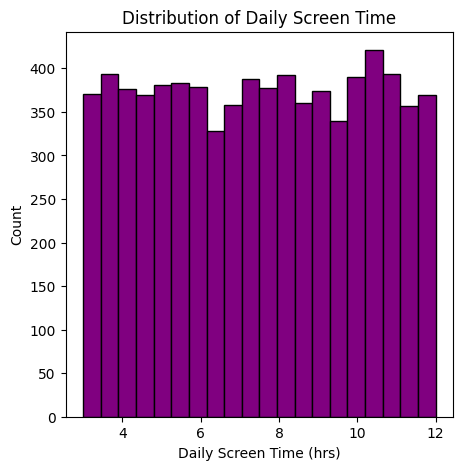

Daily Screen Time → Mean: 7.50 | Median: 7.53 | Std: 2.61


In [14]:
plt.figure(figsize=(5, 5))
plt.hist(df['daily_screen_time_hours'], bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Daily Screen Time')
plt.xlabel('Daily Screen Time (hrs)')
plt.ylabel('Count')
plt.show()
print(f"Daily Screen Time → Mean: {df['daily_screen_time_hours'].mean():.2f} | Median: {df['daily_screen_time_hours'].median():.2f} | Std: {df['daily_screen_time_hours'].std():.2f}")


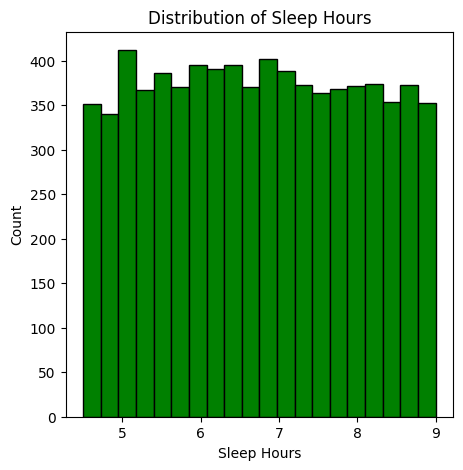

Sleep Hours → Mean: 6.74 | Median: 6.72 | Std: 1.28


In [15]:
plt.figure(figsize=(5, 5))
plt.hist(df['sleep_hours'], bins=20, color='green', edgecolor='black')
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')

plt.show()
print(f"Sleep Hours → Mean: {df['sleep_hours'].mean():.2f} | Median: {df['sleep_hours'].median():.2f} | Std: {df['sleep_hours'].std():.2f}")


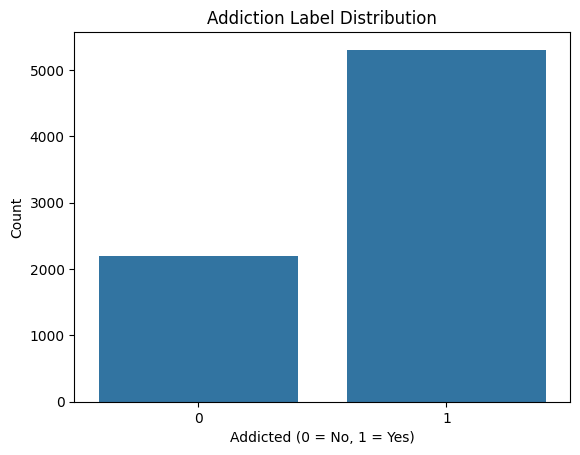

In [16]:
sns.countplot(data=df, x='addicted_label')
plt.title('Addiction Label Distribution')
plt.xlabel('Addicted (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

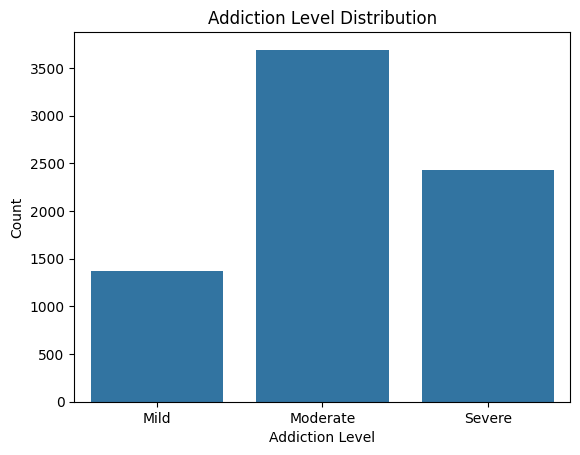

In [28]:

sns.countplot(data=df, x='addiction_level', order=[1, 2, 3])
plt.xticks(ticks=[0, 1, 2], labels=['Mild', 'Moderate', 'Severe'])
plt.title('Addiction Level Distribution')
plt.xlabel('Addiction Level')
plt.ylabel('Count')
plt.show()

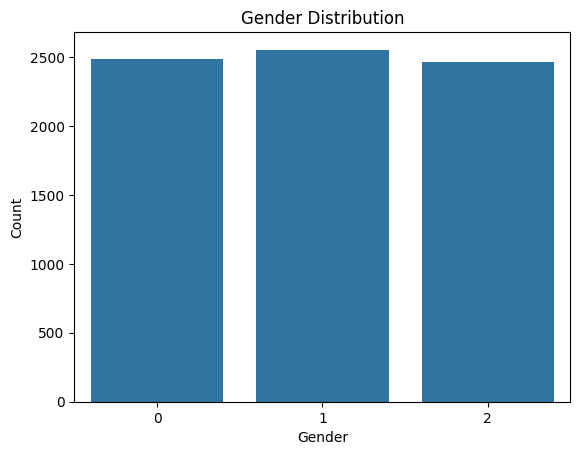

In [19]:
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

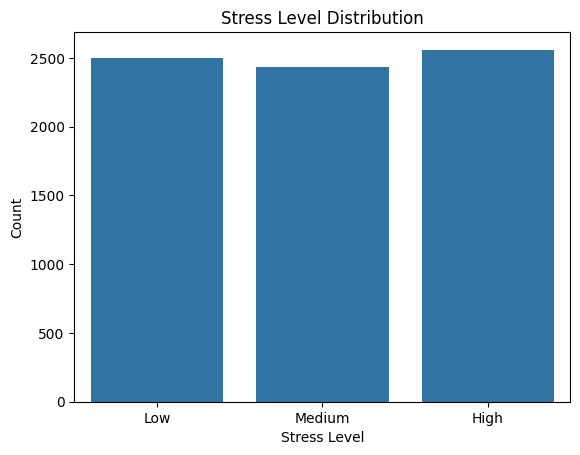

In [31]:
sns.countplot(data=df, x='stress_level', order=[0, 1, 2])
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

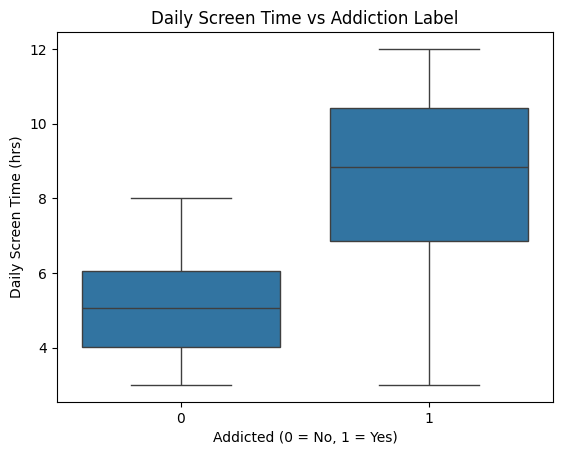

In [21]:
sns.boxplot(data=df, x='addicted_label', y='daily_screen_time_hours')
plt.title('Daily Screen Time vs Addiction Label')
plt.xlabel('Addicted (0 = No, 1 = Yes)')
plt.ylabel('Daily Screen Time (hrs)')
plt.show()

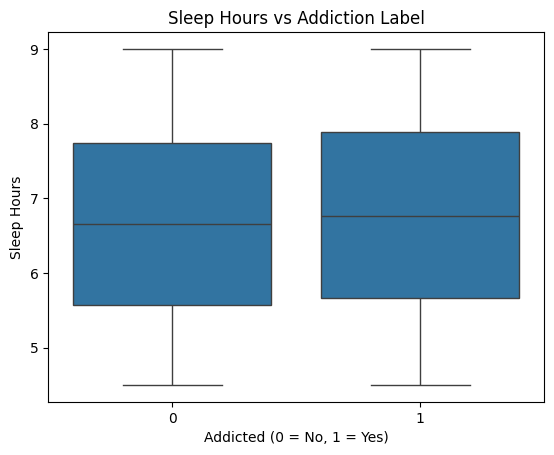

In [22]:
sns.boxplot(data=df, x='addicted_label', y='sleep_hours')
plt.title('Sleep Hours vs Addiction Label')
plt.xlabel('Addicted (0 = No, 1 = Yes)')
plt.ylabel('Sleep Hours')
plt.show()

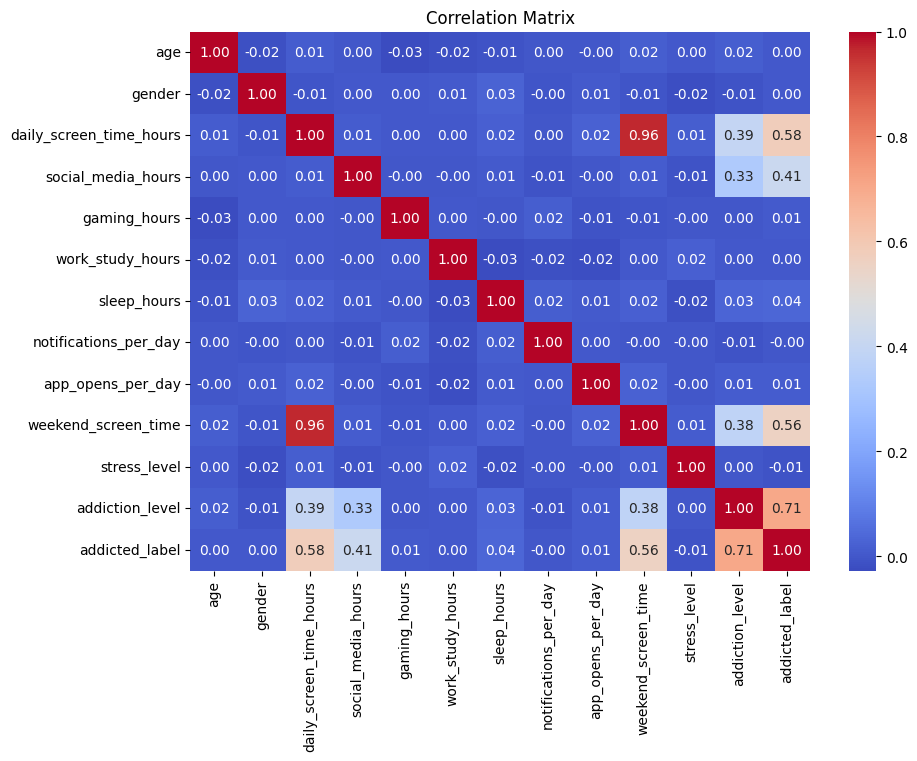

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')

plt.show()
##annot=True y3ny byshow the numbers inside each cell(Color)
##cmap='coolwarm' = red = positive, blue = negative
##df.select_dtypes(include='number')==Filters the dataframe to only keep numerical columns

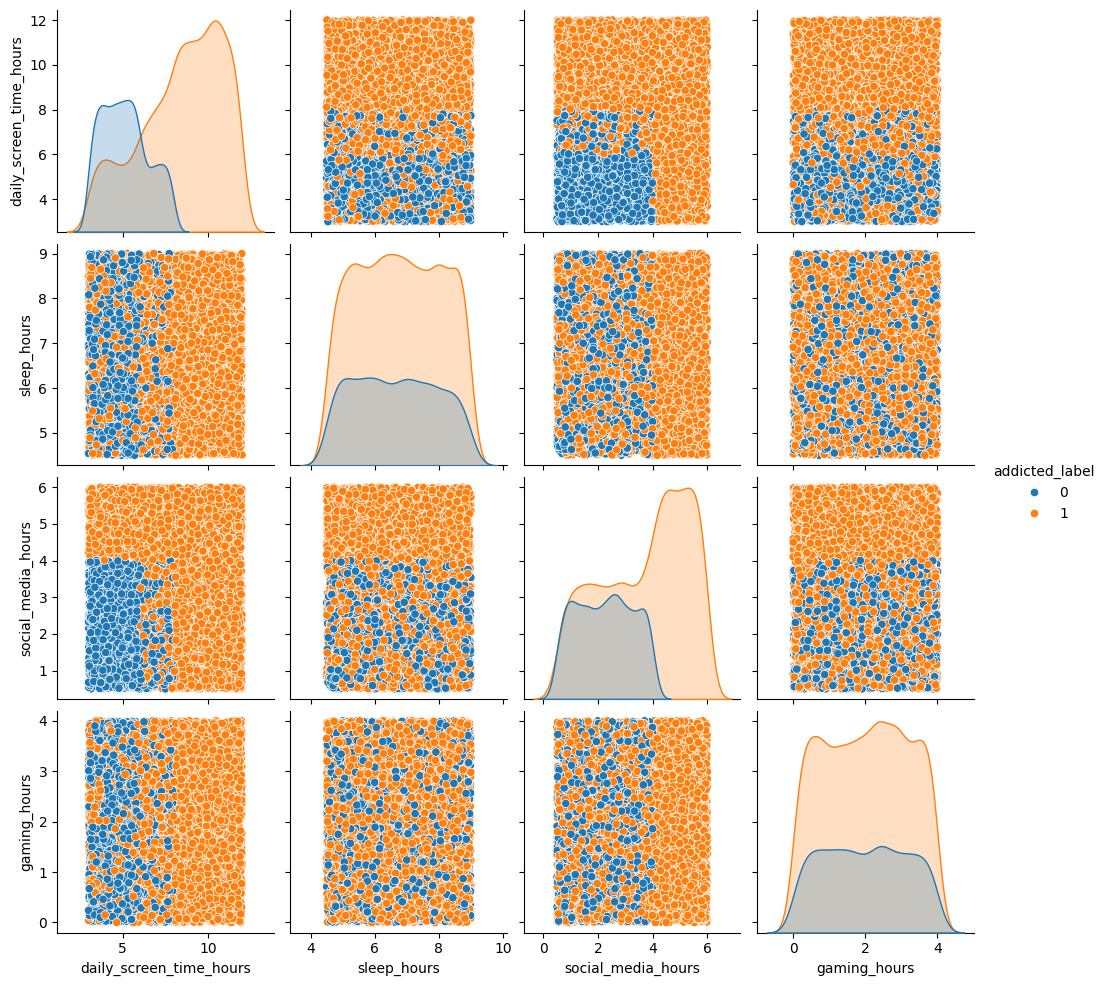

In [24]:
sns.pairplot(df[['daily_screen_time_hours', 'sleep_hours', 'social_media_hours', 'gaming_hours', 'addicted_label']],
             hue='addicted_label') ##hue by8yr lon el kwar bdl lon wa7ed
plt.show()

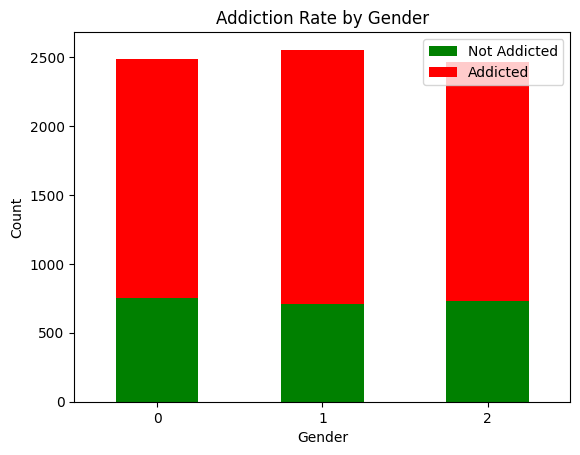

In [25]:

gender_counts = df.groupby(['gender', 'addicted_label']).size().unstack()  ##unstack female and male msh fo3 b3d
gender_counts.plot(kind='bar', stacked=True, color=['green', 'red']) ## addicted w not fo2 b3d true
plt.title('Addiction Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Not Addicted', 'Addicted'])
plt.xticks(rotation=0)  ##rotation on x axis
plt.show()

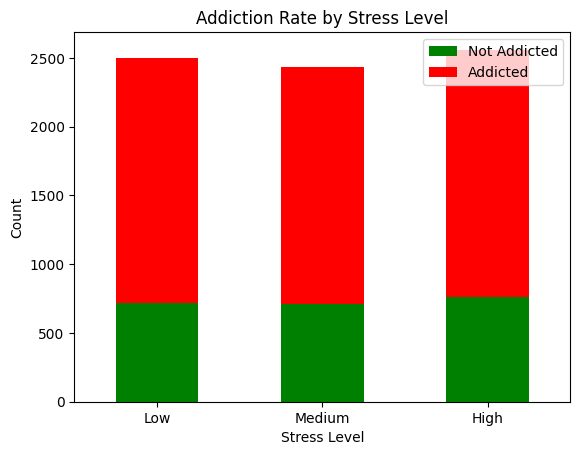

In [26]:
stress_counts = df.groupby(['stress_level', 'addicted_label']).size().unstack()

stress_counts.index = ['Low', 'Medium', 'High']

stress_counts.plot(kind='bar', stacked=True, color=['green', 'red'])
plt.title('Addiction Rate by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.legend(['Not Addicted', 'Addicted'])
plt.xticks(rotation=0)
plt.show()

**Hypothisis Testing**

**Hypothisis 1**

H₀ (null): There is no difference in mean daily screen time between addicted and non-addicted individuals.

H₁ (alternative): There is a difference in mean daily screen time between addicted and non-addicted individuals.

(t-test)

In [32]:
# H1 (t-test)
addicted_sample=df[df['addicted_label']==1]['daily_screen_time_hours']
non_addicted_sample=df[df['addicted_label']==0]['daily_screen_time_hours']


In [33]:

t_stat,pvalue = ttest_ind(addicted_sample,non_addicted_sample)
print('t-statistics:',t_stat, '\nP-value', pvalue)

t-statistics: 61.19119939768761 
P-value 0.0


reject H₀

**Hypothisis 2**

H₀: There is no linear relationship between screen time and sleep hours.

H₁: There is a linear relationship between screen time and sleep hours.

(pearson correlation test)

In [34]:
r,p=stats.pearsonr(df['daily_screen_time_hours'],df['sleep_hours'])
print(f'H2-pearson\nr= {r:.3f} \np = {p:.5f}')

H2-pearson
r= 0.019 
p = 0.09392


don't reject H₀

**Hypothisis 3**

H₀: Gender and addiction are independent (no association).

H₁: Gender and addiction are associated.

(chi-square test)


In [35]:
filtered_df = df[df['gender'].isin([1,2])]
ct = pd.crosstab(filtered_df['gender'], filtered_df['addicted_label'])
ct

addicted_label,0,1
gender,,
1,709,1844
2,733,1728


In [36]:
chi2,p,dof,excpected=stats.chi2_contingency(ct)
print(f"\nH3-(chi-square): \nchi2 = {chi2:.3f}\np= {p:.5f}")


H3-(chi-square): 
chi2 = 2.382
p= 0.12274


don't reject H₀

**Hypothisis 4**

H₀: Stress level and addiction are independent.

H₁: Stress level and addiction are associated.

(chi-square test)

In [37]:
ct1 = pd.crosstab(df['stress_level'], df['addiction_level'])
ct1

addiction_level,1,2,3
stress_level,,,
0,472,1207,824
1,431,1228,778
2,470,1258,832


In [38]:
chi2,p,dof,excpected=stats.chi2_contingency(ct1)
print(f"\nH3-(chi-square): \nchi2 = {chi2:.3f}\np= {p:.5f}")


H3-(chi-square): 
chi2 = 2.498
p= 0.64498


don't reject H₀

#**Machine Learning Modeling**

 **1) Data preparation**

In [39]:
df = pd.get_dummies(df, drop_first=True)

from sklearn.model_selection import train_test_split

X = df.drop(['addicted_label'], axis=1)
y = df['addicted_label']

**2) Split the Data**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**3) Train Multiple Models**


Logistic Regression

In [41]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Decision Tree

In [42]:

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Random Forest

In [43]:

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

# **4) Evaluate the Models**

In [44]:

models = [lr, dt, rf]

for model in models:
    y_pred = model.predict(X_test)
    print(model.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.9753333333333334
DecisionTreeClassifier 1.0
RandomForestClassifier 1.0


# **5) Confusion Matrix**

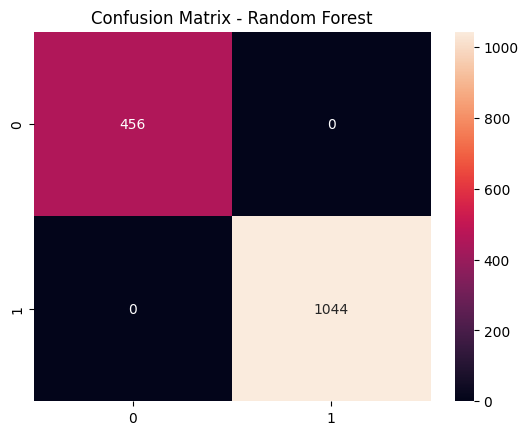

In [45]:


cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# **6) Feature Importance**

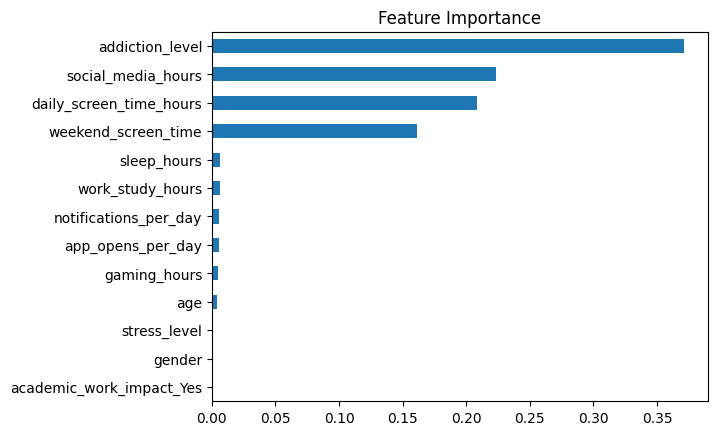

In [46]:

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()